# Week 1 · Lecture 3 — The Exponential Family and the Posterior Predictive

## Learning objectives

1. State the canonical form of an **exponential family** distribution and identify its natural parameters, sufficient statistics, and log-partition function.
2. Prove that the log-partition function is the *moment-generating function of the sufficient statistic* and use it to compute means and variances by differentiation.
3. Show that every exponential family has a **conjugate prior** in closed form, and that conjugacy in Lecture 2 was three instances of this general theorem.
4. Compute **posterior predictive** distributions in closed form for exponential-family models, and contrast them with plug-in predictions.

## 1. The exponential family

A density $p(x \mid \theta)$ is in the **exponential family** if it can be written as

$$
p(x \mid \theta) \;=\; h(x)\, \exp\!\left(\,\eta(\theta)^{\!\top}\, T(x) \;-\; A(\eta(\theta))\,\right),
$$

where:

- $\eta(\theta)$ is the **natural parameter** (a function of $\theta$);
- $T(x)$ is the **sufficient statistic** of $x$;
- $A(\eta)$ is the **log-partition function** (or *cumulant function*);
- $h(x)$ is the **base measure**.

When $\eta = \theta$ directly, we say the family is in its *natural* parametrisation. We will routinely switch between natural and "mean" parametrisations — the algebra is the same.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, special

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


### 1.1 Three examples

**Bernoulli.** With $x \in \{0, 1\}$ and parameter $\theta \in (0, 1)$,
$$
p(x \mid \theta) = \theta^x (1-\theta)^{1-x} = \exp\!\left(x \log\tfrac{\theta}{1-\theta} + \log(1-\theta)\right).
$$
So $\eta = \log\tfrac{\theta}{1-\theta}$ (the logit), $T(x) = x$, $A(\eta) = \log(1 + e^\eta)$, $h(x) = 1$.

**Poisson.**
$$
p(x \mid \lambda) = \frac{\lambda^x e^{-\lambda}}{x!} = \frac{1}{x!}\exp\!\left(x \log \lambda - \lambda\right).
$$
So $\eta = \log \lambda$, $T(x) = x$, $A(\eta) = e^\eta$, $h(x) = 1/x!$.

**Gaussian (known variance $\sigma^2$).**
$$
p(x \mid \mu) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\tfrac{(x-\mu)^2}{2\sigma^2}\right) = \underbrace{\tfrac{1}{\sqrt{2\pi\sigma^2}} e^{-x^2/2\sigma^2}}_{h(x)} \exp\!\left(\tfrac{\mu}{\sigma^2}\, x \;-\; \tfrac{\mu^2}{2\sigma^2}\right).
$$
So $\eta = \mu/\sigma^2$, $T(x) = x$, $A(\eta) = \tfrac{\sigma^2}{2}\eta^2$.

## 2. The cumulant-generating property

The log-partition function is *not* just a normaliser. Its derivatives generate moments of $T(X)$:

$$
\frac{\partial A}{\partial \eta} = \mathbb{E}[T(X)], \qquad \frac{\partial^2 A}{\partial \eta\, \partial \eta^{\!\top}} = \mathrm{Cov}[T(X)].
$$

**Proof.** From $\int h(x) \exp(\eta^\top T(x) - A(\eta))\, dx = 1$, differentiate under the integral:

$$
0 = \int h(x) (T(x) - \nabla A(\eta)) \exp(\eta^\top T(x) - A(\eta))\, dx \;=\; \mathbb{E}[T(X)] - \nabla A(\eta).
$$

A second differentiation gives the covariance. We verify this on the Poisson:


In [2]:
# Poisson: A(eta) = exp(eta), so E[T(X)] = exp(eta) = lambda, Var[T(X)] = exp(eta) = lambda
lam = 4.2
eta = np.log(lam)
A_eta = np.exp(eta)
dA = np.exp(eta)
d2A = np.exp(eta)

samples = stats.poisson.rvs(lam, size=200_000, random_state=0)
print(f"E[T(X)] from derivative of A : {dA:.4f}")
print(f"E[T(X)] empirical            : {samples.mean():.4f}")
print(f"Var[T(X)] from 2nd derivative: {d2A:.4f}")
print(f"Var[T(X)] empirical          : {samples.var():.4f}")


E[T(X)] from derivative of A : 4.2000
E[T(X)] empirical            : 4.2054
Var[T(X)] from 2nd derivative: 4.2000
Var[T(X)] empirical          : 4.2000


The agreement is to within Monte Carlo error. The cumulant-generating property is what makes exponential-family algebra so clean: gradients of $A$ are exactly the moments we want.

## 3. The natural conjugate prior

The miracle of exponential families: every member has a conjugate prior of a **standard form**.

Given likelihood $p(x \mid \eta) = h(x) \exp(\eta^\top T(x) - A(\eta))$, define the prior

$$
p(\eta \mid \nu, \tau) \;\propto\; \exp\!\left(\tau^{\!\top} \eta - \nu\, A(\eta)\right),
$$

with hyperparameters $(\nu, \tau)$. Interpretation: $\nu$ is "prior sample size", $\tau$ is "prior sum of sufficient statistics".

After observing iid data $x_1, \dots, x_N$,

$$
p(\eta \mid \mathcal{D}) \;\propto\; \exp\!\left((\tau + \textstyle\sum_i T(x_i))^{\!\top} \eta \;-\; (\nu + N) A(\eta)\right),
$$

so the posterior is the same family with $\tau' = \tau + \sum_i T(x_i)$ and $\nu' = \nu + N$.

This is *one theorem* whose three instances we worked through by hand last lecture. The Beta is the conjugate of the Bernoulli; the Gamma is the conjugate of the Poisson; the Normal is self-conjugate (mean only) and the NIG is the joint conjugate.

### Worked check: Bernoulli's natural conjugate is the Beta

For Bernoulli, $A(\eta) = \log(1 + e^\eta)$. Plug into the natural conjugate template:

$$
p(\eta \mid \nu, \tau) \;\propto\; \exp\!\left(\tau \eta - \nu \log(1 + e^\eta)\right).
$$

Change variables to $\theta = \mathrm{sigmoid}(\eta) \in (0, 1)$. With $e^\eta = \theta/(1-\theta)$ and Jacobian $d\eta/d\theta = 1/(\theta(1-\theta))$, one finds

$$
p(\theta \mid \nu, \tau) \;\propto\; \theta^{\tau - 1}(1-\theta)^{\nu - \tau - 1},
$$

i.e.\ $\mathrm{Beta}(\tau, \nu - \tau)$. So the "pseudo-counts" $(\alpha, \beta) = (\tau, \nu - \tau)$ are exactly the prior sum of successes and prior sum of failures. Let us verify computationally:


max abs difference: 2.41e-07


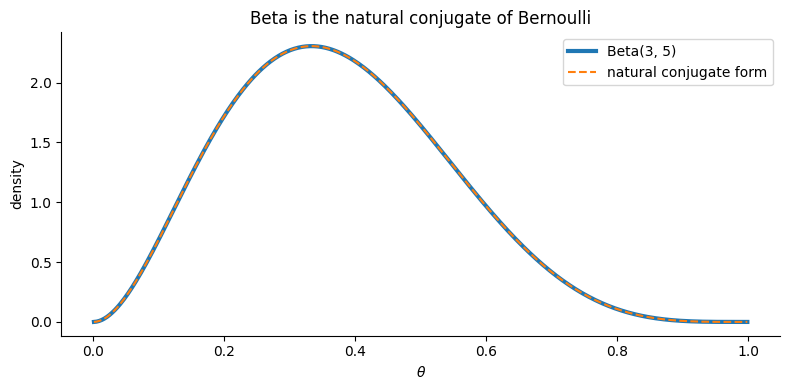

In [3]:
# Take Beta(3, 5) prior, see that it equals natural conjugate with nu=8, tau=3.
alpha, beta = 3, 5
nu, tau = alpha + beta, alpha

theta_grid = np.linspace(1e-3, 1 - 1e-3, 500)
eta_grid = np.log(theta_grid / (1 - theta_grid))

# Natural-conjugate form (on eta), transformed back to theta via Jacobian
log_p_eta = tau * eta_grid - nu * np.log1p(np.exp(eta_grid))
log_jac = -np.log(theta_grid) - np.log(1 - theta_grid)
log_p_theta = log_p_eta + log_jac
log_p_theta -= log_p_theta.max()
p_theta_natural = np.exp(log_p_theta)
p_theta_natural /= np.trapezoid(p_theta_natural, theta_grid)

p_theta_beta = stats.beta.pdf(theta_grid, alpha, beta)

print(f"max abs difference: {np.max(np.abs(p_theta_natural - p_theta_beta)):.2e}")

fig, ax = plt.subplots()
ax.plot(theta_grid, p_theta_beta, lw=3, label=f"Beta({alpha}, {beta})")
ax.plot(theta_grid, p_theta_natural, "--", lw=1.5, label="natural conjugate form")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("density")
ax.set_title("Beta is the natural conjugate of Bernoulli")
ax.legend(); plt.tight_layout(); plt.show()


## 4. The posterior predictive

The posterior predictive of a new observation is

$$
p(x_{\text{new}} \mid \mathcal{D}) \;=\; \int p(x_{\text{new}} \mid \theta)\, p(\theta \mid \mathcal{D})\, d\theta.
$$

For exponential families with conjugate priors this integral is available in closed form. Two important cases:

### Beta-Binomial $\to$ Beta-Binomial predictive
We saw this in Lecture 1. For $\mu$ future trials with $\alpha', \beta'$ posterior parameters,

$$
p(k_{\text{new}} \mid \mathcal{D}) = \binom{\mu}{k_{\text{new}}} \frac{B(\alpha' + k_{\text{new}},\ \beta' + \mu - k_{\text{new}})}{B(\alpha', \beta')}.
$$

### Gamma-Poisson $\to$ Negative-Binomial predictive
With posterior $\lambda \sim \mathrm{Gamma}(a', b')$ (shape-rate), the predictive for one new count is

$$
p(x_{\text{new}} \mid \mathcal{D}) \;=\; \int_0^\infty \frac{\lambda^{x_{\text{new}}} e^{-\lambda}}{x_{\text{new}}!}\, \frac{(b')^{a'}}{\Gamma(a')}\lambda^{a' - 1} e^{-b' \lambda}\, d\lambda \;=\; \mathrm{NB}\!\left(a',\, \tfrac{b'}{b' + 1}\right).
$$

This is a **negative binomial** with $r = a'$ trials and success probability $p = b'/(b'+1)$.

(*Derivation hint*: collect the $\lambda$ terms — you get a Gamma integral.)

Let us implement and check both predictives.


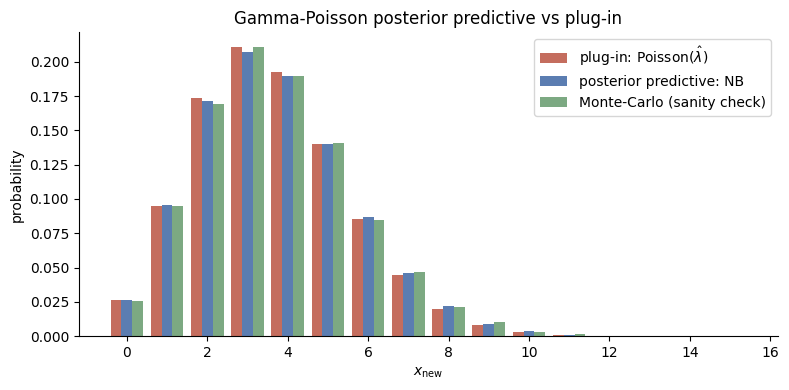

max |NB - MC|       = 0.0031  (Monte-Carlo noise)
NB std / Poisson std = 1.020


In [4]:
# --- Gamma-Poisson with closed-form NB predictive ---
rng = np.random.default_rng(3)
true_lam = 3.5
N = 30
x = stats.poisson.rvs(true_lam, size=N, random_state=rng)

a0, b0 = 2.0, 1.0
aN = a0 + x.sum()
bN = b0 + N

# Closed-form predictive: NB(r=aN, p=bN/(bN+1))
x_grid = np.arange(0, 16)
nb_pmf = stats.nbinom.pmf(x_grid, n=aN, p=bN / (bN + 1))

# Monte-Carlo predictive: sample lambda then sample x
lam_samples = stats.gamma.rvs(aN, scale=1/bN, size=20_000, random_state=rng)
x_samples = stats.poisson.rvs(lam_samples, random_state=rng)
mc_pmf = np.bincount(x_samples, minlength=x_grid.size)[: x_grid.size] / x_samples.size

# Plug-in: Poisson with lambda_MAP
lam_map = (aN - 1) / bN if aN > 1 else aN / bN
plugin_pmf = stats.poisson.pmf(x_grid, lam_map)

fig, ax = plt.subplots()
w = 0.27
ax.bar(x_grid - w, plugin_pmf, width=w, label="plug-in: Poisson($\\hat\\lambda$)", color="#C46D5E")
ax.bar(x_grid,     nb_pmf,    width=w, label="posterior predictive: NB", color="#5B7DB1")
ax.bar(x_grid + w, mc_pmf,    width=w, label="Monte-Carlo (sanity check)", color="#7CA982")
ax.set_xlabel("$x_{\\rm new}$"); ax.set_ylabel("probability")
ax.set_title("Gamma-Poisson posterior predictive vs plug-in")
ax.legend(); plt.tight_layout(); plt.show()

# Numerical check
print(f"max |NB - MC|       = {np.max(np.abs(nb_pmf - mc_pmf)):.4f}  (Monte-Carlo noise)")
print(f"NB std / Poisson std = {stats.nbinom(aN, bN/(bN+1)).std() / stats.poisson(lam_map).std():.3f}")


The posterior predictive (negative binomial) is **broader** than the plug-in Poisson — its variance is

$$
\mathrm{Var}_{\text{NB}}[x_{\text{new}}] = \frac{a' (b'+1)}{(b')^2} = \mathbb{E}[\lambda \mid \mathcal{D}] + \frac{\mathbb{E}[\lambda \mid \mathcal{D}]^2}{a'}
$$

so it is *over-dispersed* relative to Poisson, with the extra variance proportional to posterior uncertainty about $\lambda$. The plug-in predictive throws this away.

This is why Bayesian predictions are usually better-calibrated than ML predictions on small data: the Bayesian admits ignorance about $\theta$ and the predictive distribution reflects it.

## 5. Take-aways

- The exponential family unifies the conjugate priors of Lecture 2 under one general theorem.
- The log-partition function is the moment generator of $T(X)$.
- Posterior predictives in this family are closed-form distributions (Beta-Binomial, Negative-Binomial, etc.), not just numerical integrals.
- Plug-in predictives systematically under-estimate predictive variance — increasingly so as $N$ shrinks. **Always use the posterior predictive when you can compute it.**

## 6. Exercises

**Exercise 1.9 (Exponential families).** Place the Gamma, the Beta, the Multinomial, and the Multivariate Gaussian into exponential-family form. State $\eta$, $T(x)$, $A(\eta)$, and $h(x)$ in each case.

**Exercise 1.10 (Cumulant property).** Use the cumulant property to derive the mean and variance of a Beta-distributed random variable.

**Exercise 1.11 (Closed-form predictive).** Derive the Beta-Binomial predictive formula by collecting Beta-integral terms (without quoting Lecture 1's result).

**Exercise 1.12 (Project).** Implement a small `ExponentialFamily` class with methods `log_h`, `T`, `eta`, `A`, and `sample`, then test it against `scipy.stats` for Bernoulli, Poisson, and Gaussian. Show that posterior updates can be implemented generically — given an exponential family and its conjugate hyperparameters $(\nu, \tau)$, the update is `nu_new = nu + N; tau_new = tau + T(x).sum(0)`.
